<a href="https://colab.research.google.com/github/DarioCorona/personal/blob/root/NB4_Sesion2_Ejemplo_Base_Weibull_Montecarlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Módulo 4 · Estadística Aplicada y Confiabilidad de Activos
## Sesión 2 — Confiabilidad de activos y simulación de fallas

Programa de Certificación en Ciencia de Datos aplicada al Mantenimiento Predictivo

### Notebook 4 · Ejemplo base — Weibull, confiabilidad y simulación Montecarlo

**Objetivo:** estimar los parámetros de Weibull de la **Bomba Centrífuga**, calcular su función de confiabilidad R(t), y usar simulación Montecarlo para evaluar el riesgo de falla en distintos horizontes de tiempo.

Este notebook lo trabajamos juntos en sesión — es la referencia para los notebooks 5 y 6.

In [6]:
import numpy as np
import pandas as pd

# Conjunto de activos de la planta metalúrgica (mismo caso usado desde el Módulo 2).
# Cada equipo tiene un comportamiento de falla distinto (parámetros de Weibull reales
# que iremos "descubriendo" con estadística a lo largo de la sesión).
EQUIPOS = {
    "Bomba Centrífuga":       {"beta": 2.8, "eta": 850,  "n_fallas": 60},
    "Motor Eléctrico":        {"beta": 1.0, "eta": 1200, "n_fallas": 55},
    "Compresor de Aire":      {"beta": 0.6, "eta": 400,  "n_fallas": 70},
    "Ventilador Industrial":  {"beta": 2.2, "eta": 1000, "n_fallas": 50},
    "Transportador de Banda": {"beta": 1.1, "eta": 900,  "n_fallas": 58},
}

def generar_tbf(equipo, params, seed):
    """Genera tiempos entre fallas (TBF, en horas) para un equipo usando una Weibull."""
    rng = np.random.default_rng(seed)
    tbf = rng.weibull(params["beta"], params["n_fallas"]) * params["eta"]
    return pd.DataFrame({"equipo": equipo, "tbf_horas": tbf})

fallas = pd.concat(
    [generar_tbf(eq, p, seed=i) for i, (eq, p) in enumerate(EQUIPOS.items())],
    ignore_index=True,
)
fallas.head()


,equipo,tbf_horas
0,Bomba Centrífuga,740.602455
1,Bomba Centrífuga,855.912043
2,Bomba Centrífuga,209.477435
3,Bomba Centrífuga,96.626541
4,Bomba Centrífuga,686.733096


In [7]:
bomba = fallas[fallas["equipo"] == "Bomba Centrífuga"]["tbf_horas"].values
bomba[:5]

array([740.6024545 , 855.9120432 , 209.47743544,  96.62654089,
       686.73309596])

## 1. Estimación de parámetros de Weibull

Usamos `scipy.stats.weibull_min.fit` para estimar β (forma) y η (escala) por máxima verosimilitud.

In [8]:
from scipy import stats

beta, loc, eta = stats.weibull_min.fit(bomba, floc=0)
print(f"β (forma):  {beta:.2f}")
print(f"η (escala): {eta:.1f} horas")

β (forma):  2.65
η (escala): 864.5 horas


**Lectura:** β > 1 confirma que esta bomba falla predominantemente por **desgaste**: el riesgo de falla aumenta con las horas de uso, no es constante.

### Comparar contra el resto de la flota

Antes de seguir solo con la bomba, ajustemos Weibull a los 5 equipos y armemos una tabla resumen — el mismo tipo de comparación de flota que hicimos con boxplots en el Notebook 1, ahora en términos de confiabilidad.

In [10]:
resumen = []
for equipo in EQUIPOS:
    datos = fallas[fallas["equipo"] == equipo]["tbf_horas"].values
    b, l, e = stats.weibull_min.fit(datos, floc=0)
    resumen.append({
        "equipo": equipo,
        "beta": b,
        "eta": e,
        "MTBF_h": stats.weibull_min.mean(b, loc=0, scale=e),
        "B10_h": stats.weibull_min.ppf(0.10, b, loc=0, scale=e),
    })

resumen_flota = pd.DataFrame(resumen).sort_values("beta", ascending=False)
resumen_flota.round(1)

#mortalidad infantil   beta < 1  desgaste beta > 1

,equipo,beta,eta,MTBF_h,B10_h
0,Bomba Centrífuga,2.6,864.5,768.3,369.5
3,Ventilador Industrial,2.3,1019.1,902.7,377.9
4,Transportador de Banda,1.1,1057.4,1025.6,132.5
1,Motor Eléctrico,0.9,1329.1,1371.7,119.4
2,Compresor de Aire,0.7,367.4,456.2,15.8


**Lectura:** ordenado de mayor a menor β, se ve de un vistazo qué equipos se comportan por desgaste (β alto) y cuáles por falla aleatoria o mortalidad infantil (β cercano o menor a 1). Guarda esta tabla — es la misma que vas a necesitar en el Notebook 6 para decidir el intervalo óptimo de mantenimiento.

## 2. Función de confiabilidad R(t)

R(t) = 1 − F(t), la probabilidad de que el equipo siga operando sin falla después de t horas.

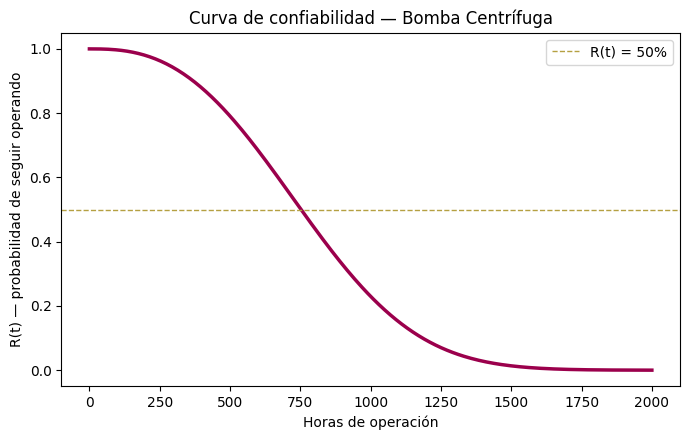

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

t = np.linspace(0, 2000, 300)
R_t = stats.weibull_min.sf(t, beta, loc=0, scale=eta)  # sf = survival function = R(t)

plt.figure(figsize=(7, 4.5))
plt.plot(t, R_t, color="#9B004C", linewidth=2.5)
plt.axhline(0.5, color="#B5A042", linestyle="--", linewidth=1, label="R(t) = 50%")
plt.title("Curva de confiabilidad — Bomba Centrífuga")
plt.xlabel("Horas de operación")
plt.ylabel("R(t) — probabilidad de seguir operando")
plt.legend()
plt.tight_layout()
plt.show()

### R(t) de toda la flota en un solo gráfico

Usando la tabla `resumen_flota`, comparamos la curva de confiabilidad de los 5 equipos — permite ver de un vistazo cuál se degrada más rápido.

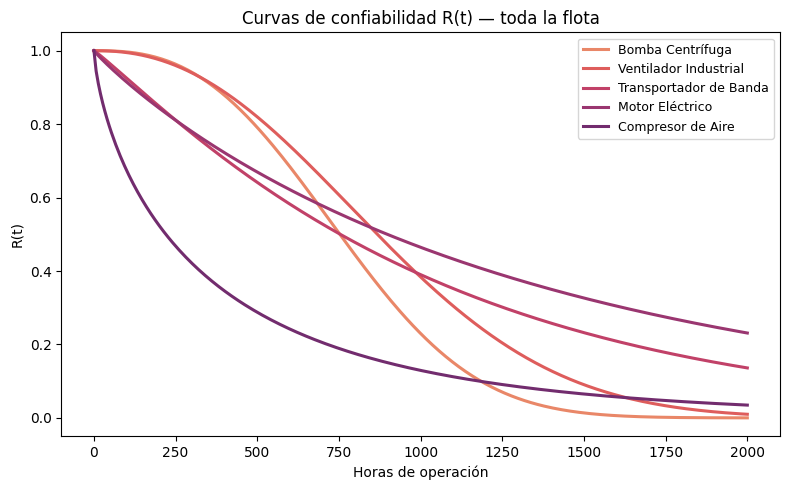

In [12]:
plt.figure(figsize=(8, 5))
paleta = sns.color_palette("flare", n_colors=len(resumen_flota))
for color, (_, fila) in zip(paleta, resumen_flota.iterrows()):
    R = stats.weibull_min.sf(t, fila["beta"], loc=0, scale=fila["eta"])
    plt.plot(t, R, label=fila["equipo"], color=color, linewidth=2.2)

plt.title("Curvas de confiabilidad R(t) — toda la flota")
plt.xlabel("Horas de operación")
plt.ylabel("R(t)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Lectura:** el equipo cuya curva cae más rápido es el que menos tiempo se puede dejar sin mantenimiento preventivo. Compáralo con el orden de la tabla `resumen_flota` — deberían coincidir.

## 3. MTBF y vida útil B10

El **MTBF** resume el tiempo medio entre fallas. La **vida útil B10** es el tiempo al que ha fallado el 10% de la población — una referencia conservadora muy usada en mantenimiento.

In [16]:
mtbf = stats.weibull_min.mean(beta, loc=0, scale=eta)
b10 = stats.weibull_min.ppf(0.10, beta, loc=0, scale=eta)

print(f"MTBF (tiempo medio entre fallas): {mtbf:.1f} h")
print(f"B10 (10% de fallas acumuladas):    {b10:.1f} h")

MTBF (tiempo medio entre fallas): 768.3 h
B10 (10% de fallas acumuladas):    369.5 h


## 4. Simulación Montecarlo

Simulamos 10,000 tiempos de falla a partir de la Weibull ajustada, para estimar el riesgo con mayor detalle que una fórmula cerrada — por ejemplo, percentiles de riesgo.  simular  10000 tiempos de falla  en una weibull ajustada funcion precargada con beta y eta

In [20]:
rng = np.random.default_rng(7)
simulaciones = stats.weibull_min.rvs(beta, loc=0, scale=eta, size=10_000, random_state=rng)

p10, p50, p90 = np.percentile(simulaciones, [10, 50, 90])
print(f"P10 (10% más pesimista): {p10:.1f} h")  # a las 367 horas  va a  fallar  una bomba
print(f"Mediana simulada:        {p50:.1f} h")  # no es el promedio, es el valor  en medio de los set de datos falla  a las 754.3 hrs
print(f"P90 (10% más optimista): {p90:.1f} h")  # falla a las 1192

P10 (10% más pesimista): 367.5 h
Mediana simulada:        754.3 h
P90 (10% más optimista): 1192.3 h


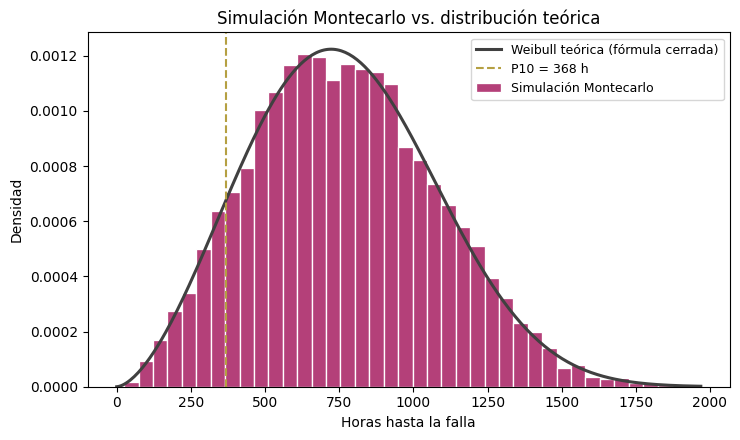

In [19]:
x_pdf = np.linspace(0, simulaciones.max(), 300)
pdf_teorica = stats.weibull_min.pdf(x_pdf, beta, loc=0, scale=eta)

plt.figure(figsize=(7.5, 4.5))
sns.histplot(simulaciones, bins=40, stat="density", color="#9B004C", edgecolor="white", label="Simulación Montecarlo")
plt.plot(x_pdf, pdf_teorica, color="#404040", linewidth=2.2, label="Weibull teórica (fórmula cerrada)")
plt.axvline(p10, color="#B5A042", linestyle="--", label=f"P10 = {p10:.0f} h")
plt.title("Simulación Montecarlo vs. distribución teórica")
plt.xlabel("Horas hasta la falla")
plt.ylabel("Densidad")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Por qué importa esta comparación:** si el histograma de la simulación se superpone bien con la curva teórica, confirmamos que la simulación Montecarlo es consistente con el modelo Weibull ajustado — no está introduciendo sesgos adicionales. Es el mismo tipo de chequeo visual que hicimos en el Notebook 1 al comparar el histograma real contra las densidades ajustadas.

## 5. Recomendación de intervalo de mantenimiento

Usando el percentil P10 como referencia conservadora ("prefiero cambiar el componente un poco antes que arriesgarme a que falle"), ¿qué intervalo de mantenimiento preventivo recomendarías para esta bomba? Compáralo contra el MTBF: ¿cuánta "vida útil" estás dejando sin usar por seguridad?